# Brain Tumor MRI Data Preprocessing with Data Preservation

This notebook implements preprocessing steps for Brain Tumor MRI images while preserving the original data by:
1. Creating backup copies of original data
2. Applying preprocessing on copied data
3. Maintaining data integrity throughout the process

## 1. Import Required Libraries

In [1]:
import os
import shutil
import numpy as np
import torch
import torchvision
from torchvision import transforms
import cv2
from pathlib import Path
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print("GPU is available!")
else:
    print("GPU is not available. Using CPU.")

GPU is available!


## 2. Setup Directory Paths and Constants

In [2]:
# Original data paths
ORIGINAL_BASE_DIR = r"C:\Users\manav\Documents\lighTumorNet\Brain_Tumor_MRI_Dataset"
ORIGINAL_TRAIN_DIR = os.path.join(ORIGINAL_BASE_DIR, "Training")
ORIGINAL_TEST_DIR = os.path.join(ORIGINAL_BASE_DIR, "Testing")

# Create new directory for preprocessed data
PROCESSED_BASE_DIR = os.path.join(os.path.dirname(ORIGINAL_BASE_DIR), "Processed_Brain_Tumor_MRI_Dataset")
PROCESSED_TRAIN_DIR = os.path.join(PROCESSED_BASE_DIR, "Training")
PROCESSED_TEST_DIR = os.path.join(PROCESSED_BASE_DIR, "Testing")

# Image parameters
IMG_HEIGHT = 150
IMG_WIDTH = 150
CHANNELS = 3
BATCH_SIZE = 32

# Create processed directories if they don't exist
os.makedirs(PROCESSED_BASE_DIR, exist_ok=True)
os.makedirs(PROCESSED_TRAIN_DIR, exist_ok=True)
os.makedirs(PROCESSED_TEST_DIR, exist_ok=True)

# Class names
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Create class directories in processed folders
for class_name in CLASS_NAMES:
    os.makedirs(os.path.join(PROCESSED_TRAIN_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(PROCESSED_TEST_DIR, class_name), exist_ok=True)

print("Directory structure created successfully!")

Directory structure created successfully!


## 3. Create Data Loading and Preprocessing Functions

In [ ]:
def load_and_preprocess_image(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    """
    Load and preprocess a single image while preserving the original
    """
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image at {image_path}")
    
    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize the image
    img_resized = cv2.resize(img, target_size)
    
    # Normalize pixel values
    img_normalized = img_resized / 255.0
    
    return img_normalized


def copy_and_preprocess_directory(src_dir, dst_dir):
    """
    Copy and preprocess all images from source to destination directory
    """
    if not os.path.exists(src_dir):
        print(f"Source directory {src_dir} does not exist!")
        return
    
    # Create destination directory if it doesn't exist
    os.makedirs(dst_dir, exist_ok=True)
    
    # Process all images in the directory
    for img_name in os.listdir(src_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            src_path = os.path.join(src_dir, img_name)
            dst_path = os.path.join(dst_dir, img_name)
            
            try:
                # Preprocess the image
                processed_img = load_and_preprocess_image(src_path)
                
                # Save the preprocessed image
                plt.imsave(dst_path, processed_img)
                
            except Exception as e:
                print(f"Error processing {img_name}: {str(e)}")
                continue
    
    print(f"Processed all images in {src_dir} to {dst_dir}")

# PyTorch transforms for training and testing
# Note: many torchvision transforms expect PIL images; ensure numpy arrays
# are converted to PIL images before applying these transforms.
from PIL import Image

train_transform = transforms.Compose([
    transforms.Lambda(lambda img: Image.fromarray(img) if isinstance(img, (np.ndarray,)) else img),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.002, 0.002), shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Lambda(lambda img: Image.fromarray(img) if isinstance(img, (np.ndarray,)) else img),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 4. Process Training and Testing Data

In [4]:
# Process training data
for class_name in CLASS_NAMES:
    src_dir = os.path.join(ORIGINAL_TRAIN_DIR, class_name)
    dst_dir = os.path.join(PROCESSED_TRAIN_DIR, class_name)
    
    if os.path.exists(src_dir):
        print(f"Processing training data for class: {class_name}")
        copy_and_preprocess_directory(src_dir, dst_dir)
    else:
        print(f"Warning: Training directory for {class_name} not found at {src_dir}")

# Process testing data
for class_name in CLASS_NAMES:
    src_dir = os.path.join(ORIGINAL_TEST_DIR, class_name)
    dst_dir = os.path.join(PROCESSED_TEST_DIR, class_name)
    
    if os.path.exists(src_dir):
        print(f"Processing testing data for class: {class_name}")
        copy_and_preprocess_directory(src_dir, dst_dir)
    else:
        print(f"Warning: Testing directory for {class_name} not found at {src_dir}")

Processing training data for class: glioma
Processed all images in C:\Users\manav\Documents\lighTumorNet\Brain_Tumor_MRI_Dataset\Training\glioma to C:\Users\manav\Documents\lighTumorNet\Processed_Brain_Tumor_MRI_Dataset\Training\glioma
Processing training data for class: meningioma
Processed all images in C:\Users\manav\Documents\lighTumorNet\Brain_Tumor_MRI_Dataset\Training\glioma to C:\Users\manav\Documents\lighTumorNet\Processed_Brain_Tumor_MRI_Dataset\Training\glioma
Processing training data for class: meningioma
Processed all images in C:\Users\manav\Documents\lighTumorNet\Brain_Tumor_MRI_Dataset\Training\meningioma to C:\Users\manav\Documents\lighTumorNet\Processed_Brain_Tumor_MRI_Dataset\Training\meningioma
Processing training data for class: notumor
Processed all images in C:\Users\manav\Documents\lighTumorNet\Brain_Tumor_MRI_Dataset\Training\meningioma to C:\Users\manav\Documents\lighTumorNet\Processed_Brain_Tumor_MRI_Dataset\Training\meningioma
Processing training data for cl

## 5. Set Up Data Generators

In [ ]:
class BrainTumorDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = CLASS_NAMES
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            if os.path.exists(class_dir):
                for img_name in os.listdir(class_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.samples.append((
                            os.path.join(class_dir, img_name),
                            self.class_to_idx[class_name]
                        ))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = cv2.imread(img_path)
        if image is None:
            # If an image fails to load, raise a descriptive error
            raise ValueError(f"Failed to read image at {img_path}")
        # Convert BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # At this point `image` is a HxWxC numpy array (RGB). Our transforms
        # include a Lambda that converts numpy arrays to PIL.Image when needed.
        if self.transform:
            image = self.transform(image)
        
        return image, int(label)

# Choose a safe number of workers for Windows notebooks (spawn issues otherwise)
if os.name == 'nt':
    _num_workers = 0
else:
    _num_workers = min(4, (os.cpu_count() or 1))

# Create datasets
train_dataset = BrainTumorDataset(
    root_dir=PROCESSED_TRAIN_DIR,
    transform=train_transform
)

test_dataset = BrainTumorDataset(
    root_dir=PROCESSED_TEST_DIR,
    transform=test_transform
)

# Create data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=_num_workers,
    pin_memory=True if torch.cuda.is_available() else False,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=_num_workers,
    pin_memory=True if torch.cuda.is_available() else False,
)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")
print(f"Number of classes: {len(CLASS_NAMES)}")

Number of training samples: 5712
Number of testing samples: 1311
Number of classes: 4


## 6. Verify Data Processing

In [6]:
def verify_data_processing():
    """
    Verify that the data has been processed correctly
    """
    # Check directory structure
    for split in ['Training', 'Testing']:
        for class_name in CLASS_NAMES:
            original_dir = os.path.join(ORIGINAL_BASE_DIR, split, class_name)
            processed_dir = os.path.join(PROCESSED_BASE_DIR, split, class_name)
            
            if os.path.exists(original_dir) and os.path.exists(processed_dir):
                original_count = len([f for f in os.listdir(original_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                processed_count = len([f for f in os.listdir(processed_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                
                print(f"{split}/{class_name}:")
                print(f"  Original images: {original_count}")
                print(f"  Processed images: {processed_count}")
                print(f"  Status: {'✓' if original_count == processed_count else '✗'}\n")
            else:
                print(f"Warning: Directory not found - {original_dir} or {processed_dir}")

# Run verification
verify_data_processing()

Training/glioma:
  Original images: 1321
  Processed images: 1321
  Status: ✓

Training/meningioma:
  Original images: 1339
  Processed images: 1339
  Status: ✓

Training/notumor:
  Original images: 1595
  Processed images: 1595
  Status: ✓

Training/pituitary:
  Original images: 1457
  Processed images: 1457
  Status: ✓

Testing/glioma:
  Original images: 300
  Processed images: 300
  Status: ✓

Testing/meningioma:
  Original images: 306
  Processed images: 306
  Status: ✓

Testing/notumor:
  Original images: 405
  Processed images: 405
  Status: ✓

Testing/pituitary:
  Original images: 300
  Processed images: 300
  Status: ✓



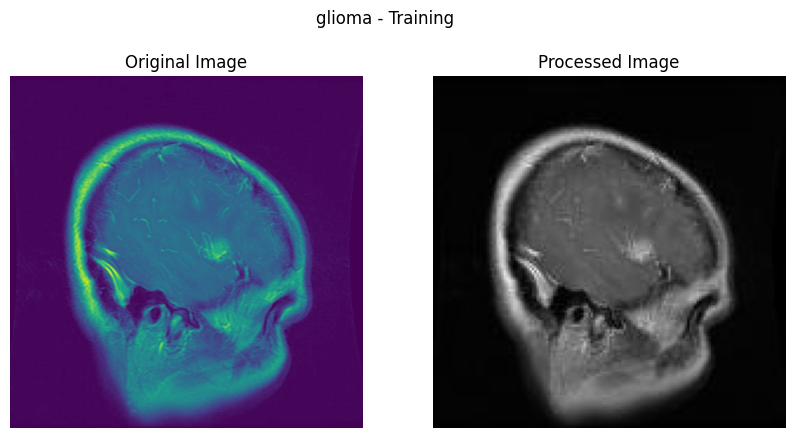

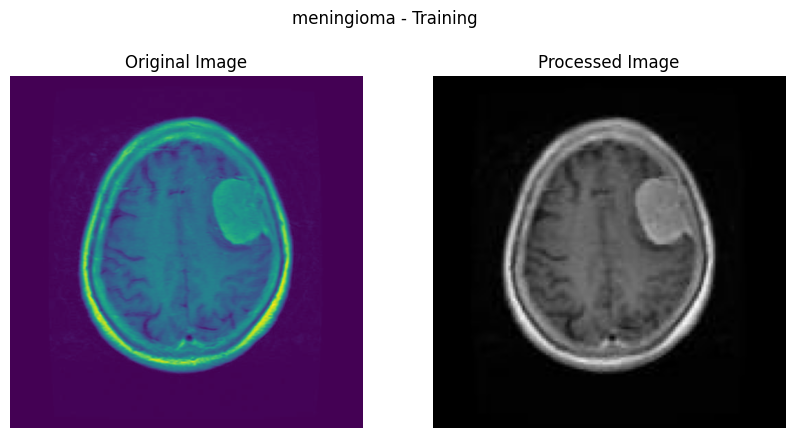

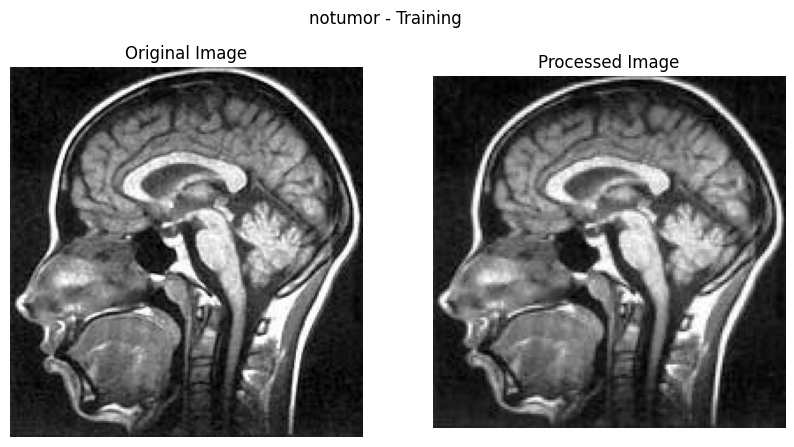

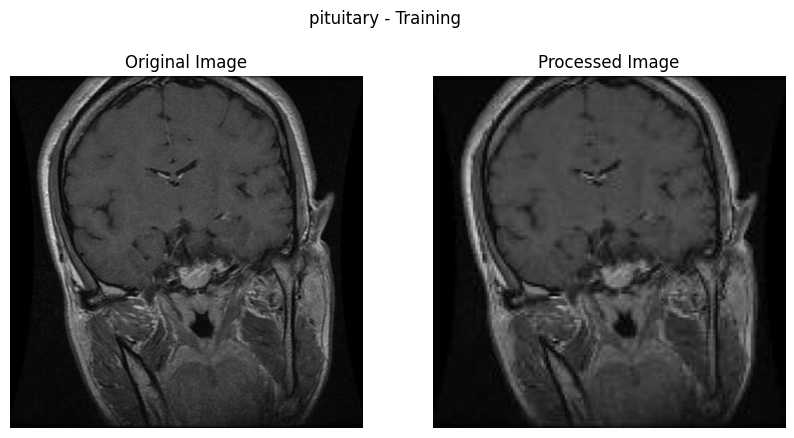

In [8]:
# Display sample images for verification
def display_sample_images(class_name, split='Training'):
    """
    Display original and processed images side by side for comparison
    """
    original_dir = os.path.join(ORIGINAL_BASE_DIR, split, class_name)
    processed_dir = os.path.join(PROCESSED_BASE_DIR, split, class_name)
    
    if not (os.path.exists(original_dir) and os.path.exists(processed_dir)):
        print(f"Directories not found for {class_name}")
        return
    
    # Get a random image
    images = [f for f in os.listdir(original_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not images:
        print(f"No images found for {class_name}")
        return
    
    sample_image = np.random.choice(images)
    
    # Read original and processed images
    original_img = plt.imread(os.path.join(original_dir, sample_image))
    processed_img = plt.imread(os.path.join(processed_dir, sample_image))
    
    # Display images
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(original_img)
    ax1.set_title('Original Image')
    ax1.axis('off')
    
    ax2.imshow(processed_img)
    ax2.set_title('Processed Image')
    ax2.axis('off')
    
    plt.suptitle(f"{class_name} - {split}")
    plt.show()

# Display sample images for each class
for class_name in CLASS_NAMES:
    display_sample_images(class_name)

In [10]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import seaborn as sns
from sklearn.preprocessing import label_binarize

# Define the CNN model
class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BrainTumorCNN, self).__init__()
        self.features = nn.Sequential(
            # Convolutional layer 1
            nn.Conv2d(3, 32, kernel_size=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Convolutional layer 2
            nn.Conv2d(32, 64, kernel_size=2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Convolutional layer 3
            nn.Conv2d(64, 128, kernel_size=2),
            nn.ReLU()
        )
        
        # Calculate the size of flattened features
        self.flatten_size = self._get_flatten_size()
        
        self.classifier = nn.Sequential(
            nn.Linear(self.flatten_size, 512),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(512, num_classes)
            # Note: do NOT apply Softmax here because CrossEntropyLoss expects raw logits
        )
    
    def _get_flatten_size(self):
        # Pass a dummy input through the convolutional layers to get the output size
        x = torch.randn(1, 3, IMG_HEIGHT, IMG_WIDTH)
        x = self.features(x)
        return x.numel() // x.size(0)
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Initialize model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BrainTumorCNN(num_classes=len(CLASS_NAMES)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, betas=(0.869, 0.995))
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Print model summary
print(model)

BrainTumorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(2, 2), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(2, 2), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(2, 2), stride=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=156800, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.35, inplace=False)
    (3): Linear(in_features=512, out_features=4, bias=True)
    (4): Softmax(dim=1)
  )
)


c:\Users\manav\miniconda3\envs\efficientnet\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader) if len(train_loader) > 0 else 0.0
    epoch_acc = 100. * correct / total if total > 0 else 0.0
    return epoch_loss, epoch_acc

# Evaluation function
def evaluate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(test_loader) if len(test_loader) > 0 else 0.0
    epoch_acc = 100. * correct / total if total > 0 else 0.0
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

# Training loop
epochs = 50
best_val_loss = float('inf')
patience = 6
patience_counter = 0
train_losses = []
train_accs = []
val_losses = []
val_accs = []

# Pre-check: ensure datasets are non-empty before starting training
if len(train_dataset) == 0 or len(test_dataset) == 0:
    print("No training or testing samples found. Please check the data directories:")
    print(f"  Processed training dir: {PROCESSED_TRAIN_DIR} (samples: {len(train_dataset)})")
    print(f"  Processed testing dir:  {PROCESSED_TEST_DIR} (samples: {len(test_dataset)})")
    print("If you haven't processed/copy the original dataset, run the preprocessing cells first.")
else:
    print("Starting training...")
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, test_loader, criterion, device)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs}:')
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save the best model
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered!")
                break
                
    print("Training completed!")

Starting training...


In [ ]:
# Plot training history
plt.figure(figsize=(15, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accs, linewidth=3, color='#39e75f', label='Train')
plt.plot(val_accs, linewidth=3, color='#8f00ff', label='Validation')
plt.title('Model Accuracy', fontsize=20)
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=16)
plt.legend(fontsize=16)
plt.grid(alpha=0.1)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(train_losses, linewidth=3, color='#39e75f', label='Train')
plt.plot(val_losses, linewidth=3, color='#8f00ff', label='Validation')
plt.title('Model Loss', fontsize=20)
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.legend(fontsize=16)
plt.grid(alpha=0.1)

plt.tight_layout()
plt.show()

# Load best model and evaluate
model.load_state_dict(torch.load('best_model.pth'))
_, _, y_pred_prob, y_true = evaluate(model, test_loader, criterion, device)

# Plot ROC curves
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(CLASS_NAMES):
    class_name_title_case = class_name.title()
    y_true_bin = label_binarize(y_true, classes=range(len(CLASS_NAMES)))
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name_title_case} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Compute and plot confusion matrix
y_pred = np.argmax(y_pred_prob, axis=1)
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(ticks=np.arange(len(CLASS_NAMES)) + 0.5,
          labels=[name.title() for name in CLASS_NAMES], ha='center')
plt.yticks(ticks=np.arange(len(CLASS_NAMES)) + 0.5,
          labels=[name.title() for name in CLASS_NAMES], va='center')
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, 
                          target_names=[name.title() for name in CLASS_NAMES],
                          digits=6))

In [ ]:
def plot_sample_predictions(model, test_loader, num_samples=9, figsize=(12, 8)):
    """
    Display sample predictions from the model
    """
    model.eval()
    all_images = []
    all_labels = []
    all_preds = []
    
    # Get a batch of images
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            
            # Convert back to numpy for visualization
            images_np = images.cpu().numpy()
            labels_np = labels.numpy()
            preds_np = predicted.cpu().numpy()
            
            # Transpose images from (B, C, H, W) to (B, H, W, C)
            images_np = np.transpose(images_np, (0, 2, 3, 1))
            
            # Denormalize images
            images_np = images_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            images_np = np.clip(images_np, 0, 1)
            
            all_images.extend(images_np)
            all_labels.extend(labels_np)
            all_preds.extend(preds_np)
            
            if len(all_images) >= num_samples:
                break
    
    # Plot sample images with their predicted and true labels
    plt.figure(figsize=figsize)
    for i in range(min(num_samples, len(all_images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(all_images[i])
        plt.axis("off")
        
        # Set title color based on prediction correctness
        prediction_color = 'green' if all_preds[i] == all_labels[i] else 'red'
        plt.title(f"Pred: {CLASS_NAMES[all_preds[i]].title()}\nTrue: {CLASS_NAMES[all_labels[i]].title()}", 
                 color=prediction_color)
    
    plt.tight_layout()
    plt.show()

# Display sample predictions
plot_sample_predictions(model, test_loader)